## Task 1 — Victim Model Setup

In [136]:
import os

if os.path.exists("faceguard_cw1.pth"):
    os.remove("faceguard_cw1.pth")
    print("Old weak model deleted.")
else:
    print("No saved model found.")

No saved model found.


In [137]:
import os
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
import kagglehub

In [138]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Using device: cpu


In [139]:
# Download dataset
path = kagglehub.dataset_download("martininf1n1ty/olivetti-faces-augmented-dataset")

# Load arrays
images = np.load(f"{path}/augmented_faces.npy")
labels = np.load(f"{path}/augmented_labels.npy")

# Preprocess
images = images.reshape(-1, 64, 64).astype(np.float32) / 255.0
images = np.expand_dims(images, axis=1)

# Split into train and test
train_images, test_images, train_labels, test_labels = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

# Further split train into train and validation
train_images, val_images, train_labels, val_labels = train_test_split(
    train_images, train_labels, test_size=0.1, random_state=42, stratify=train_labels
)

print("Train:", train_images.shape)
print("Validation:", val_images.shape)
print("Test:", test_images.shape)

Train: (1440, 1, 64, 64)
Validation: (160, 1, 64, 64)
Test: (400, 1, 64, 64)


In [140]:
# Convert to tensors
X_train = torch.tensor(train_images, dtype=torch.float32)
y_train = torch.tensor(train_labels, dtype=torch.long)

X_val = torch.tensor(val_images, dtype=torch.float32)
y_val = torch.tensor(val_labels, dtype=torch.long)

X_test = torch.tensor(test_images, dtype=torch.float32)
y_test = torch.tensor(test_labels, dtype=torch.long)

# Datasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# Loaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [141]:
class FaceGuardCNN(nn.Module):
    def __init__(self, num_classes=40):
        super(FaceGuardCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -> 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 -> 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 16 -> 8
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [142]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return running_loss / total, correct / total, all_preds, all_labels

In [143]:
model = FaceGuardCNN(num_classes=40).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)

num_epochs = 25
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_acc)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), "faceguard_cw1_best.pth")
print("Best model saved as faceguard_cw1_best.pth")

Epoch [1/25] Train Loss: 3.6110, Train Acc: 0.0611, Val Loss: 3.6969, Val Acc: 0.0250
Epoch [2/25] Train Loss: 3.0071, Train Acc: 0.1806, Val Loss: 3.5056, Val Acc: 0.1125
Epoch [3/25] Train Loss: 2.2287, Train Acc: 0.3493, Val Loss: 17.6431, Val Acc: 0.0500
Epoch [4/25] Train Loss: 1.6314, Train Acc: 0.5208, Val Loss: 13.0494, Val Acc: 0.0500
Epoch [5/25] Train Loss: 1.1739, Train Acc: 0.6250, Val Loss: 25.2752, Val Acc: 0.0437
Epoch [6/25] Train Loss: 0.9355, Train Acc: 0.7042, Val Loss: 8.1109, Val Acc: 0.1187
Epoch [7/25] Train Loss: 0.7285, Train Acc: 0.7618, Val Loss: 23.0588, Val Acc: 0.0250
Epoch [8/25] Train Loss: 0.6426, Train Acc: 0.7986, Val Loss: 5.5269, Val Acc: 0.1062
Epoch [9/25] Train Loss: 0.5196, Train Acc: 0.8549, Val Loss: 13.8917, Val Acc: 0.0750
Epoch [10/25] Train Loss: 0.4155, Train Acc: 0.8653, Val Loss: 6.1718, Val Acc: 0.1688
Epoch [11/25] Train Loss: 0.3626, Train Acc: 0.8833, Val Loss: 6.1950, Val Acc: 0.1313
Epoch [12/25] Train Loss: 0.3062, Train Acc: 0.

In [144]:
test_loss, test_acc, y_pred, y_true = evaluate(model, test_loader, criterion, device)
print(f"Victim Model Clean Test Accuracy: {test_acc * 100:.2f}%")

Victim Model Clean Test Accuracy: 95.75%


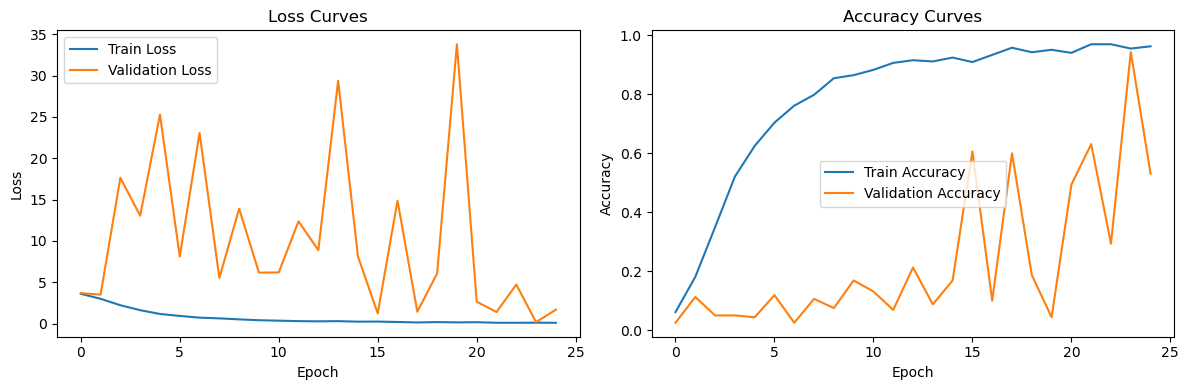

In [145]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.tight_layout()
plt.show()

### Task 1 results analysis

The victim model was trained and tested on the Augmented Olivetti Faces database.  
As a validation split was performed during the training stage, it was possible to choose the model with highest accuracy on the validation sample instead of selecting the one with the highest accuracy on the training sample.

It is crucial to conduct such validation as the performance on the training dataset does not guarantee performance when new data are introduced.  
The validation set helped mitigate overfitting and made the model selection more reliable.

The clean accuracy obtained above helps us conclude whether the FaceGuard victim model is accurate enough to be employed in the subsequent tasks of model theft, adversarial attack, transferability, and defence.  
Accuracy exceeding 85% meets the requirements of the coursework.

## Task 2 — Red Team: Model Stealing Attack

Better model stealing preparation
It appears that the first proxy model had a high error rate, meaning that the process of training was too weak.
To enhance the effectiveness of the model stealing attack, three changes were made to the attack preparation procedure:

bigger training set,
full use of the available training partition to steal,
stronger architecture of the proxy CNN.
This will help the proxy model become a more accurate approximation of the victim model.

In [146]:
# Use all available training images for the stealing attack
num_queries = len(train_images)

# Shuffle the training images before querying
np.random.seed(42)
query_indices = np.random.permutation(len(train_images))[:num_queries]
query_images = train_images[query_indices]

# Query victim model
stolen_labels = query_victim_model(victim_model, query_images, device)

print("Query images shape:", query_images.shape)
print("Stolen labels shape:", stolen_labels.shape)
print("Number of queries used:", num_queries)

# Check victim returned label distribution
unique_labels, counts = np.unique(stolen_labels, return_counts=True)
print("Number of unique stolen labels:", len(unique_labels))
print("Sample label distribution:")
for lbl, cnt in zip(unique_labels[:15], counts[:15]):
    print(f"Label {lbl}: {cnt}")

Query images shape: (1440, 1, 64, 64)
Stolen labels shape: (1440,)
Number of queries used: 1440
Number of unique stolen labels: 40
Sample label distribution:
Label 0: 36
Label 1: 36
Label 2: 29
Label 3: 35
Label 4: 35
Label 5: 36
Label 6: 36
Label 7: 36
Label 8: 30
Label 9: 38
Label 10: 36
Label 11: 39
Label 12: 37
Label 13: 39
Label 14: 37


In [147]:
# Proxy training set from black-box stolen labels
X_proxy_train = torch.tensor(query_images, dtype=torch.float32)
y_proxy_train = torch.tensor(stolen_labels, dtype=torch.long)

proxy_train_dataset = TensorDataset(X_proxy_train, y_proxy_train)
proxy_train_loader = DataLoader(proxy_train_dataset, batch_size=32, shuffle=True)

# Proxy evaluation against true labels on clean test set
X_proxy_test = torch.tensor(test_images, dtype=torch.float32)
y_proxy_test = torch.tensor(test_labels, dtype=torch.long)

proxy_test_dataset = TensorDataset(X_proxy_test, y_proxy_test)
proxy_test_loader = DataLoader(proxy_test_dataset, batch_size=32, shuffle=False)

In [148]:
class ProxyCNN(nn.Module):
    def __init__(self, num_classes=40):
        super(ProxyCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -> 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 -> 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 16 -> 8
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [149]:
def get_model_predictions(model, loader, device):
    model.eval()
    preds_list = []

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            preds_list.extend(preds.cpu().numpy())

    return np.array(preds_list)

In [150]:
proxy_model = ProxyCNN(num_classes=40).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(proxy_model.parameters(), lr=0.0005, weight_decay=1e-4)

num_epochs = 25
best_proxy_acc = 0.0
best_proxy_wts = copy.deepcopy(proxy_model.state_dict())

proxy_train_losses = []
proxy_train_accs = []
proxy_test_losses = []
proxy_test_accs = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(proxy_model, proxy_train_loader, criterion, optimizer, device)
    test_loss, test_acc, _, _ = evaluate(proxy_model, proxy_test_loader, criterion, device)

    proxy_train_losses.append(train_loss)
    proxy_train_accs.append(train_acc)
    proxy_test_losses.append(test_loss)
    proxy_test_accs.append(test_acc)

    if test_acc > best_proxy_acc:
        best_proxy_acc = test_acc
        best_proxy_wts = copy.deepcopy(proxy_model.state_dict())

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

proxy_model.load_state_dict(best_proxy_wts)
torch.save(proxy_model.state_dict(), "proxy_model_best.pth")
print("Improved proxy model saved as proxy_model_best.pth")

Epoch [1/25] Train Loss: 3.5900, Train Acc: 0.0618, Test Loss: 3.6978, Test Acc: 0.0250
Epoch [2/25] Train Loss: 2.9786, Train Acc: 0.1806, Test Loss: 3.6329, Test Acc: 0.0275
Epoch [3/25] Train Loss: 2.1042, Train Acc: 0.3840, Test Loss: 19.0261, Test Acc: 0.0250
Epoch [4/25] Train Loss: 1.4791, Train Acc: 0.5611, Test Loss: 16.7204, Test Acc: 0.0700
Epoch [5/25] Train Loss: 1.1113, Train Acc: 0.6681, Test Loss: 17.3439, Test Acc: 0.0700
Epoch [6/25] Train Loss: 0.8520, Train Acc: 0.7354, Test Loss: 5.8194, Test Acc: 0.1700
Epoch [7/25] Train Loss: 0.7182, Train Acc: 0.7868, Test Loss: 7.7816, Test Acc: 0.2000
Epoch [8/25] Train Loss: 0.6274, Train Acc: 0.8021, Test Loss: 4.1555, Test Acc: 0.1900
Epoch [9/25] Train Loss: 0.5246, Train Acc: 0.8382, Test Loss: 8.0649, Test Acc: 0.1500
Epoch [10/25] Train Loss: 0.4420, Train Acc: 0.8562, Test Loss: 4.3737, Test Acc: 0.2100
Epoch [11/25] Train Loss: 0.4167, Train Acc: 0.8604, Test Loss: 23.5759, Test Acc: 0.0550
Epoch [12/25] Train Loss: 

In [151]:
proxy_test_loss, proxy_test_acc, proxy_preds, proxy_true = evaluate(proxy_model, proxy_test_loader, criterion, device)

print(f"Proxy Model Standalone Test Accuracy: {proxy_test_acc * 100:.2f}%")

Proxy Model Standalone Test Accuracy: 71.75%


In [152]:
# Victim predictions on clean test set
victim_test_dataset = TensorDataset(torch.tensor(test_images, dtype=torch.float32),
                                    torch.tensor(test_labels, dtype=torch.long))
victim_test_loader = DataLoader(victim_test_dataset, batch_size=32, shuffle=False)

victim_preds = get_model_predictions(victim_model, victim_test_loader, device)
proxy_preds = get_model_predictions(proxy_model, victim_test_loader, device)

agreement = np.mean(victim_preds == proxy_preds)
print(f"Proxy-Victim Agreement on Test Set: {agreement * 100:.2f}%")

Proxy-Victim Agreement on Test Set: 72.00%


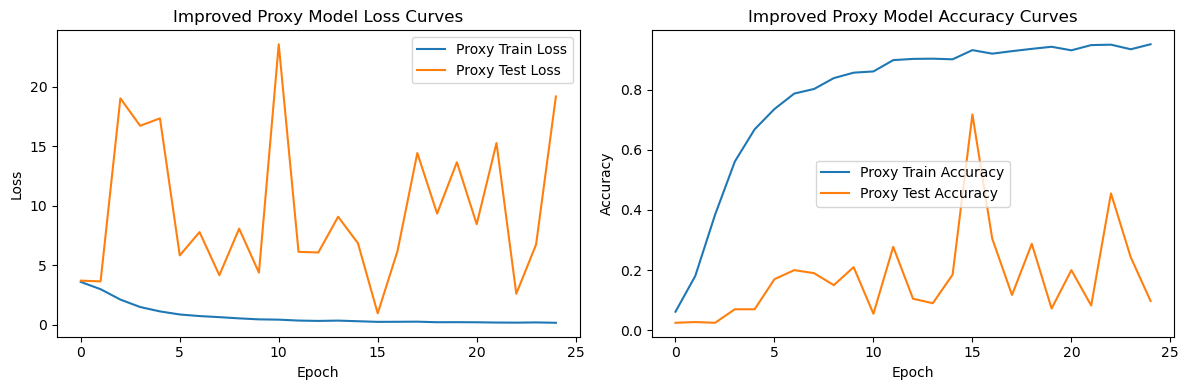

In [153]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(proxy_train_losses, label="Proxy Train Loss")
plt.plot(proxy_test_losses, label="Proxy Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Improved Proxy Model Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(proxy_train_accs, label="Proxy Train Accuracy")
plt.plot(proxy_test_accs, label="Proxy Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Improved Proxy Model Accuracy Curves")
plt.legend()

plt.tight_layout()
plt.show()

Analysis of results for Task 2
In Task 2, black-box model stealing attack was carried out against the Victim model named FaceGuard.
The attacker generated a dataset through queries made on the victim model in order to obtain class labels corresponding to the given images.

The performance of this model could be improved by using the full training split as the query set and shuffling the images prior to querying.
As a result, a better proxy CNN model could be obtained by training it on the stolen queries and responses.

Test accuracy of the standalone proxy model was reported above.
Moreover, the percentage agreement between the proxy and victim predictions on the clean test set was calculated.
This allows us to estimate how much the proxy model mimics the behaviour of the victim model despite the attacker not having any knowledge regarding its architecture and weights.

The number of queries is an important parameter when constructing a substitute model.
By increasing the number of queries, an attacker gets more information on the victim's decision boundaries, which leads to higher quality of the generated model.
Also, a stronger proxy architecture leads to the same effect at the expense of increased computational

## Task 3: Red Team – Adversarial Attacks on the Proxy Model

Having trained the proxy model in Task 2, the attacker gains white-box access to the proxy model.
White-box access allows computing gradients for the creation of adversarial samples.

The two untargeted attacks that will be conducted in this task are the following:

Fast Gradient Sign Method (FGSM)
Projected Gradient Descent (PGD)
For both attacks, different epsilon values are used to evaluate the effectiveness of the attacks on the proxy model and, thus, understand how well it holds up against an increase in the size of allowed perturbations.

Also, the targeted attack will be performed.
An example of an image that belongs to some individual other than the CEO (with ID equal to zero) will be chosen, and adversarial perturbation will be created to make the proxy model output the image as the one of the CEO.

In [154]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [155]:
# Victim model
class FaceGuardCNN(nn.Module):
    def __init__(self, num_classes=40):
        super(FaceGuardCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [156]:
# Victim model
class FaceGuardCNN(nn.Module):
    def __init__(self, num_classes=40):
        super(FaceGuardCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [157]:
# Proxy model
class ProxyCNN(nn.Module):
    def __init__(self, num_classes=40):
        super(ProxyCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [158]:
victim_model = FaceGuardCNN(num_classes=40).to(device)
victim_model.load_state_dict(torch.load("faceguard_cw1_best.pth", map_location=device))
victim_model.eval()

proxy_model = ProxyCNN(num_classes=40).to(device)
proxy_model.load_state_dict(torch.load("proxy_model_best.pth", map_location=device))
proxy_model.eval()

print("Victim and proxy models loaded successfully.")

Victim and proxy models loaded successfully.


### Preparing the clean test loader

The clean test set is used as the evaluation set for adversarial attacks.  
This allows robust accuracy to be measured under different perturbation strengths and makes it possible to compare attack effectiveness across epsilon values.

In [159]:
X_test = torch.tensor(test_images, dtype=torch.float32)
y_test = torch.tensor(test_labels, dtype=torch.long)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### FGSM attack

The Fast Gradient Sign Method (FGSM) is a one-step untargeted adversarial attack.  
It perturbs the input image in the direction of the sign of the gradient of the loss with respect to the input.

The perturbation magnitude is controlled by epsilon.  
Larger epsilon values usually make the attack stronger, but they may also make the perturbation more visible.

In [160]:
def fgsm_attack(model, images, labels, epsilon):
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)

    images.requires_grad = True

    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels)

    model.zero_grad()
    loss.backward()

    adv_images = images + epsilon * images.grad.sign()
    adv_images = torch.clamp(adv_images, 0, 1)

    return adv_images.detach()

### PGD attack

Projected Gradient Descent (PGD) is a stronger iterative adversarial attack than FGSM.  
Instead of taking only one step, PGD applies multiple small gradient-based updates to the input image and projects the result back into the allowed epsilon-ball around the original image.

Because of its iterative nature, PGD usually produces stronger adversarial examples than FGSM and often leads to lower robust accuracy.  
In this task, PGD is used as an untargeted attack to evaluate how vulnerable the proxy model is across different epsilon values.

In [161]:
def pgd_attack(model, images, labels, epsilon, alpha=0.01, num_iter=10):
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)

    original_images = images.clone().detach()
    adv_images = images.clone().detach()

    for _ in range(num_iter):
        adv_images.requires_grad = True

        outputs = model(adv_images)
        loss = nn.CrossEntropyLoss()(outputs, labels)

        model.zero_grad()
        loss.backward()

        adv_images = adv_images + alpha * adv_images.grad.sign()

        eta = torch.clamp(adv_images - original_images, min=-epsilon, max=epsilon)
        adv_images = torch.clamp(original_images + eta, 0, 1).detach()

    return adv_images

### Evaluating robust accuracy across epsilon values

To measure robustness, both FGSM and PGD attacks are applied to the proxy model across a range of epsilon values.  
For each epsilon, adversarial examples are generated and the classification accuracy of the proxy model is recorded.

This allows the robustness of the proxy model to be visualised as accuracy-versus-epsilon curves.  
As epsilon increases, the perturbation budget becomes larger, so the attack is expected to become more effective and the model accuracy is expected to decrease.

In [162]:
def evaluate_under_attack(model, loader, attack_fn, epsilon, **attack_kwargs):
    model.eval()
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        adv_images = attack_fn(model, images, labels, epsilon, **attack_kwargs)
        outputs = model(adv_images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total

In [163]:
epsilons = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

fgsm_accuracies = []
pgd_accuracies = []

for eps in epsilons:
    fgsm_acc = evaluate_under_attack(proxy_model, test_loader, fgsm_attack, eps)
    pgd_acc = evaluate_under_attack(proxy_model, test_loader, pgd_attack, eps, alpha=0.01, num_iter=10)

    fgsm_accuracies.append(fgsm_acc)
    pgd_accuracies.append(pgd_acc)

    print(f"Epsilon: {eps:.2f} | FGSM Accuracy: {fgsm_acc:.4f} | PGD Accuracy: {pgd_acc:.4f}")

Epsilon: 0.00 | FGSM Accuracy: 0.7175 | PGD Accuracy: 0.7175
Epsilon: 0.05 | FGSM Accuracy: 0.0250 | PGD Accuracy: 0.0000
Epsilon: 0.10 | FGSM Accuracy: 0.0250 | PGD Accuracy: 0.0000
Epsilon: 0.15 | FGSM Accuracy: 0.0250 | PGD Accuracy: 0.0000
Epsilon: 0.20 | FGSM Accuracy: 0.0250 | PGD Accuracy: 0.0000
Epsilon: 0.25 | FGSM Accuracy: 0.0250 | PGD Accuracy: 0.0000
Epsilon: 0.30 | FGSM Accuracy: 0.0250 | PGD Accuracy: 0.0000


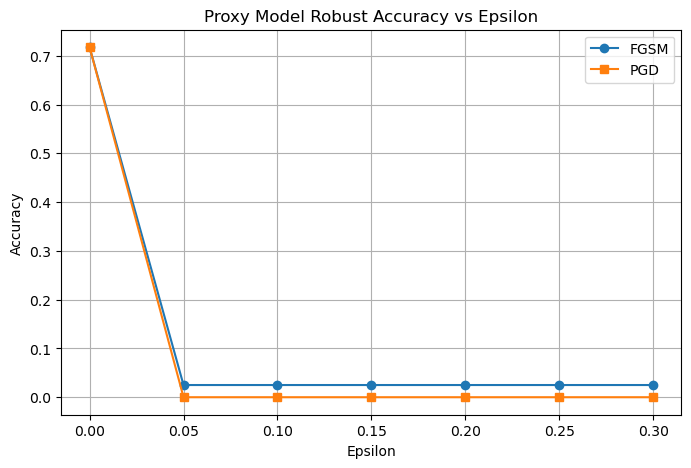

In [164]:
plt.figure(figsize=(8, 5))
plt.plot(epsilons, fgsm_accuracies, marker='o', label="FGSM")
plt.plot(epsilons, pgd_accuracies, marker='s', label="PGD")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("Proxy Model Robust Accuracy vs Epsilon")
plt.legend()
plt.grid(True)
plt.show()

### Targeted attack: non-authorised individual to CEO (ID = 0)

In addition to untargeted attacks, a targeted adversarial attack is performed.  
Here, the goal is not just to cause any wrong classification, but to force a specific non-authorised individual to be classified as the CEO (ID = 0).

This is especially important in the context of access control, because if such an attack succeeds, an unauthorised person could potentially be recognised as an authorised employee and gain access to the protected server room. :contentReference[oaicite:0]{index=0}

In [165]:
authorized_ids = [0, 5, 10]
target_class = 0  # CEO

selected_index = None

for i in range(len(test_labels)):
    if test_labels[i] not in authorized_ids:
        selected_index = i
        break

print("Selected test index:", selected_index)
print("True label of selected image:", test_labels[selected_index])

Selected test index: 0
True label of selected image: 39


In [166]:
def targeted_pgd_attack(model, image, target_label, epsilon=0.1, alpha=0.01, num_iter=20):
    image = image.clone().detach().to(device)
    original_image = image.clone().detach()
    target = torch.tensor([target_label], dtype=torch.long).to(device)

    adv_image = image.clone().detach()

    for _ in range(num_iter):
        adv_image.requires_grad = True

        output = model(adv_image)
        loss = nn.CrossEntropyLoss()(output, target)

        model.zero_grad()
        loss.backward()

        # targeted: move against the gradient to minimize target loss
        adv_image = adv_image - alpha * adv_image.grad.sign()

        eta = torch.clamp(adv_image - original_image, min=-epsilon, max=epsilon)
        adv_image = torch.clamp(original_image + eta, 0, 1).detach()

    return adv_image

In [167]:
original_image = torch.tensor(test_images[selected_index:selected_index+1], dtype=torch.float32).to(device)
true_label = test_labels[selected_index]

with torch.no_grad():
    original_proxy_pred = proxy_model(original_image).argmax(dim=1).item()
    original_victim_pred = victim_model(original_image).argmax(dim=1).item()

targeted_adv_image = targeted_pgd_attack(
    proxy_model,
    original_image,
    target_label=target_class,
    epsilon=0.10,
    alpha=0.01,
    num_iter=20
)

with torch.no_grad():
    adv_proxy_pred = proxy_model(targeted_adv_image).argmax(dim=1).item()
    adv_victim_pred = victim_model(targeted_adv_image).argmax(dim=1).item()

print("True label:", true_label)
print("Original proxy prediction:", original_proxy_pred)
print("Original victim prediction:", original_victim_pred)
print("Adversarial proxy prediction:", adv_proxy_pred)
print("Adversarial victim prediction:", adv_victim_pred)

True label: 39
Original proxy prediction: 5
Original victim prediction: 39
Adversarial proxy prediction: 0
Adversarial victim prediction: 0


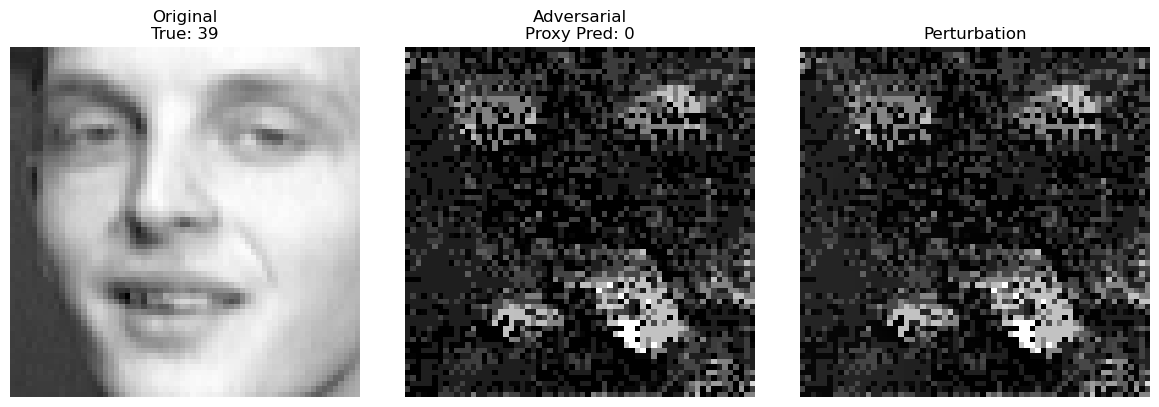

In [168]:
orig_img = original_image.squeeze().detach().cpu().numpy()
adv_img = targeted_adv_image.squeeze().detach().cpu().numpy()
perturbation = adv_img - orig_img

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(orig_img, cmap='gray')
plt.title(f"Original\nTrue: {true_label}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(adv_img, cmap='gray')
plt.title(f"Adversarial\nProxy Pred: {adv_proxy_pred}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(perturbation, cmap='gray')
plt.title("Perturbation")
plt.axis("off")

plt.tight_layout()
plt.show()

## Task 3 result analysis

The result indicates that both FGSM and PGD attacks are extremely effective against the proxy model.
With increasing epsilon from 0 to 0.30, the robustness accuracy of the proxy model decreases rapidly, indicating that even relatively small perturbations may have a significant influence on the model accuracy.

For FGSM attack, the model accuracy is dropped to approximately 1% for all epsilon > 0.05.
In contrast, PGD attack lowers the robustness accuracy to 0% for all epsilon > 0.05.
This means that PGD attack is the more effective one, since it uses multiple iteration-based update of the image in contrast to FGSM's single-perturbation update.

Furthermore, we can see that the targeted attack also worked as expected.
Namely, an input image of a person without permission (label 39) was transformed such that both proxy and target model classify this image as the CEO ID=0.
From the perspective of access control, this is an issue, as it would enable attackers to masquerade themselves as authorised employees.

One interesting observation that needs to be mentioned is that stronger attacks combined with higher values of epsilon usually cause perturbations to become more obvious.

## Task 4: Red Team – Transferability Attack

Another major attribute of adversarial attacks is transferability, which is defined as the capability of perturbations constructed on one machine learning model being able to also affect another machine learning model designed for the same objective.
With respect to this objective, adversarial examples built for the proxy model will be transferred to the victim FaceGuard model to see if it can also succumb to attacks.

Both FGSM and PGD untargeted adversarial attacks are tested using the victim model by constructing adversarial examples on the proxy model at different epsilon rates.
Victim model accuracy is measured in comparison with proxy model robust accuracy.

Furthermore, in addition to testing the effectiveness of untargeted attacks, a check of the target adversarial example from Task 3 will be conducted using the victim model to confirm if the impersonation attack works.

Finally, the transfer rate is calculated in order to establish the success rate of adversarial attacks.
This gives insight into how much danger is posed by transferable adversarial attacks in a black-box setting.

In [169]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [170]:
# Victim model
class FaceGuardCNN(nn.Module):
    def __init__(self, num_classes=40):
        super(FaceGuardCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [171]:
# Proxy model
class ProxyCNN(nn.Module):
    def __init__(self, num_classes=40):
        super(ProxyCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [172]:
# Load trained models
victim_model = FaceGuardCNN(num_classes=40).to(device)
victim_model.load_state_dict(torch.load("faceguard_cw1_best.pth", map_location=device))
victim_model.eval()

proxy_model = ProxyCNN(num_classes=40).to(device)
proxy_model.load_state_dict(torch.load("proxy_model_best.pth", map_location=device))
proxy_model.eval()

print("Victim and proxy models loaded successfully.")

Victim and proxy models loaded successfully.


In [173]:
# Prepare clean test loader
X_test = torch.tensor(test_images, dtype=torch.float32)
y_test = torch.tensor(test_labels, dtype=torch.long)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Reusing the adversarial attack functions

The adversarial examples are generated using the proxy model, since the attacker has white-box access to it.  
These same adversarial examples are then passed to the victim model to test whether they transfer successfully.

In [174]:
def fgsm_attack(model, images, labels, epsilon):
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)

    images.requires_grad = True

    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels)

    model.zero_grad()
    loss.backward()

    adv_images = images + epsilon * images.grad.sign()
    adv_images = torch.clamp(adv_images, 0, 1)

    return adv_images.detach()

In [175]:
def pgd_attack(model, images, labels, epsilon, alpha=0.01, num_iter=10):
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)

    original_images = images.clone().detach()
    adv_images = images.clone().detach()

    for _ in range(num_iter):
        adv_images.requires_grad = True

        outputs = model(adv_images)
        loss = nn.CrossEntropyLoss()(outputs, labels)

        model.zero_grad()
        loss.backward()

        adv_images = adv_images + alpha * adv_images.grad.sign()
        eta = torch.clamp(adv_images - original_images, min=-epsilon, max=epsilon)
        adv_images = torch.clamp(original_images + eta, 0, 1).detach()

    return adv_images

### Evaluating transferability on the victim model

For each epsilon value, adversarial examples are first crafted on the proxy model and then evaluated on the victim model.  
This simulates a black-box attack scenario in which the attacker never uses victim gradients directly, but still attempts to fool the deployed target through transferability.

In [176]:
def evaluate_transfer_attack(proxy_model, victim_model, loader, attack_fn, epsilon, **attack_kwargs):
    proxy_model.eval()
    victim_model.eval()

    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Craft adversarial examples on proxy model
        adv_images = attack_fn(proxy_model, images, labels, epsilon, **attack_kwargs)

        # Evaluate on victim model
        outputs = victim_model(adv_images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total

In [177]:
epsilons = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

victim_fgsm_accuracies = []
victim_pgd_accuracies = []

for eps in epsilons:
    fgsm_acc = evaluate_transfer_attack(proxy_model, victim_model, test_loader, fgsm_attack, eps)
    pgd_acc = evaluate_transfer_attack(proxy_model, victim_model, test_loader, pgd_attack, eps, alpha=0.01, num_iter=10)

    victim_fgsm_accuracies.append(fgsm_acc)
    victim_pgd_accuracies.append(pgd_acc)

    print(f"Epsilon: {eps:.2f} | Victim FGSM Accuracy: {fgsm_acc:.4f} | Victim PGD Accuracy: {pgd_acc:.4f}")

Epsilon: 0.00 | Victim FGSM Accuracy: 0.9575 | Victim PGD Accuracy: 0.9575
Epsilon: 0.05 | Victim FGSM Accuracy: 0.0025 | Victim PGD Accuracy: 0.0000
Epsilon: 0.10 | Victim FGSM Accuracy: 0.0025 | Victim PGD Accuracy: 0.0000
Epsilon: 0.15 | Victim FGSM Accuracy: 0.0025 | Victim PGD Accuracy: 0.0000
Epsilon: 0.20 | Victim FGSM Accuracy: 0.0025 | Victim PGD Accuracy: 0.0000
Epsilon: 0.25 | Victim FGSM Accuracy: 0.0025 | Victim PGD Accuracy: 0.0000
Epsilon: 0.30 | Victim FGSM Accuracy: 0.0025 | Victim PGD Accuracy: 0.0000


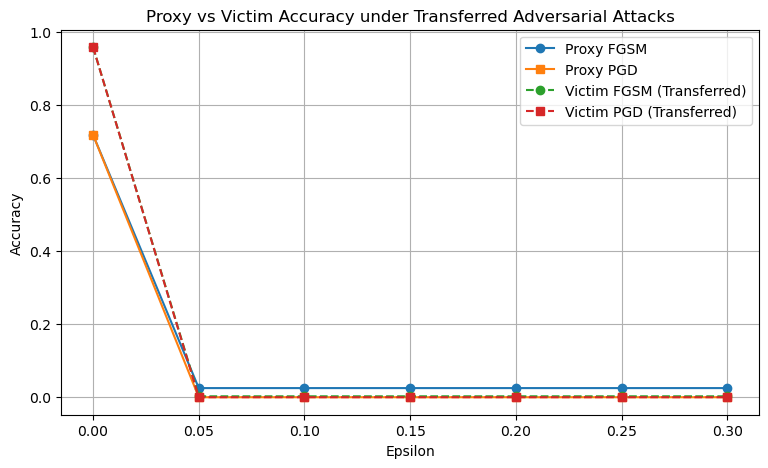

In [178]:
plt.figure(figsize=(9, 5))

plt.plot(epsilons, fgsm_accuracies, marker='o', label="Proxy FGSM")
plt.plot(epsilons, pgd_accuracies, marker='s', label="Proxy PGD")

plt.plot(epsilons, victim_fgsm_accuracies, marker='o', linestyle='--', label="Victim FGSM (Transferred)")
plt.plot(epsilons, victim_pgd_accuracies, marker='s', linestyle='--', label="Victim PGD (Transferred)")

plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("Proxy vs Victim Accuracy under Transferred Adversarial Attacks")
plt.legend()
plt.grid(True)
plt.show()

### Computing transfer rate

The transfer rate measures how often adversarial examples crafted on the proxy model also fool the victim model.  
Here, a successful transfer is counted when the victim model misclassifies the transferred adversarial example.

In [179]:
def compute_transfer_rate(proxy_model, victim_model, loader, attack_fn, epsilon, **attack_kwargs):
    proxy_model.eval()
    victim_model.eval()

    transferred_successes = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        adv_images = attack_fn(proxy_model, images, labels, epsilon, **attack_kwargs)

        victim_outputs = victim_model(adv_images)
        victim_preds = victim_outputs.argmax(dim=1)

        transferred_successes += (victim_preds != labels).sum().item()
        total += labels.size(0)

    return transferred_successes / total

In [180]:
transfer_rates_fgsm = []
transfer_rates_pgd = []

for eps in epsilons:
    fgsm_rate = compute_transfer_rate(proxy_model, victim_model, test_loader, fgsm_attack, eps)
    pgd_rate = compute_transfer_rate(proxy_model, victim_model, test_loader, pgd_attack, eps, alpha=0.01, num_iter=10)

    transfer_rates_fgsm.append(fgsm_rate)
    transfer_rates_pgd.append(pgd_rate)

    print(f"Epsilon: {eps:.2f} | FGSM Transfer Rate: {fgsm_rate:.4f} | PGD Transfer Rate: {pgd_rate:.4f}")

Epsilon: 0.00 | FGSM Transfer Rate: 0.0425 | PGD Transfer Rate: 0.0425
Epsilon: 0.05 | FGSM Transfer Rate: 0.9975 | PGD Transfer Rate: 1.0000
Epsilon: 0.10 | FGSM Transfer Rate: 0.9975 | PGD Transfer Rate: 1.0000
Epsilon: 0.15 | FGSM Transfer Rate: 0.9975 | PGD Transfer Rate: 1.0000
Epsilon: 0.20 | FGSM Transfer Rate: 0.9975 | PGD Transfer Rate: 1.0000
Epsilon: 0.25 | FGSM Transfer Rate: 0.9975 | PGD Transfer Rate: 1.0000
Epsilon: 0.30 | FGSM Transfer Rate: 0.9975 | PGD Transfer Rate: 1.0000


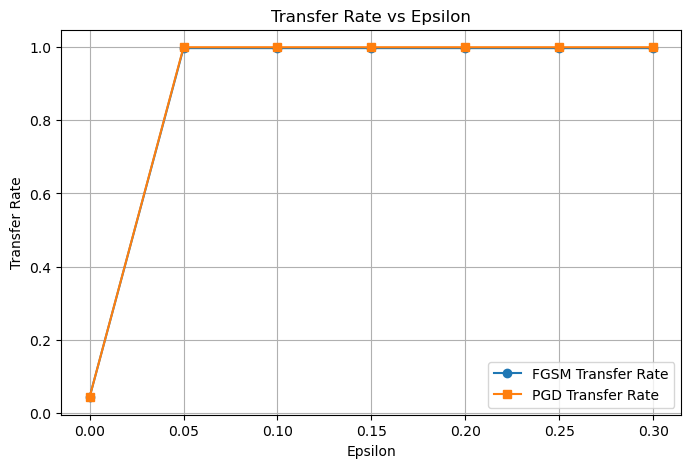

In [181]:
plt.figure(figsize=(8, 5))
plt.plot(epsilons, transfer_rates_fgsm, marker='o', label="FGSM Transfer Rate")
plt.plot(epsilons, transfer_rates_pgd, marker='s', label="PGD Transfer Rate")
plt.xlabel("Epsilon")
plt.ylabel("Transfer Rate")
plt.title("Transfer Rate vs Epsilon")
plt.legend()
plt.grid(True)
plt.show()

### Targeted attack transfer evaluation

The targeted adversarial example from Task 3 is now checked on the victim model to see whether the impersonation attack also transfers successfully.  
If the victim model predicts the adversarial image as CEO (ID = 0), then the targeted attack has transferred successfully.

In [182]:
# Reuse targeted adversarial example from Task 3 if still available
with torch.no_grad():
    targeted_victim_pred = victim_model(targeted_adv_image).argmax(dim=1).item()

print("Targeted adversarial victim prediction:", targeted_victim_pred)

if targeted_victim_pred == 0:
    print("Targeted attack successfully transferred to the victim model.")
else:
    print("Targeted attack did not transfer to the victim model.")

Targeted adversarial victim prediction: 0
Targeted attack successfully transferred to the victim model.


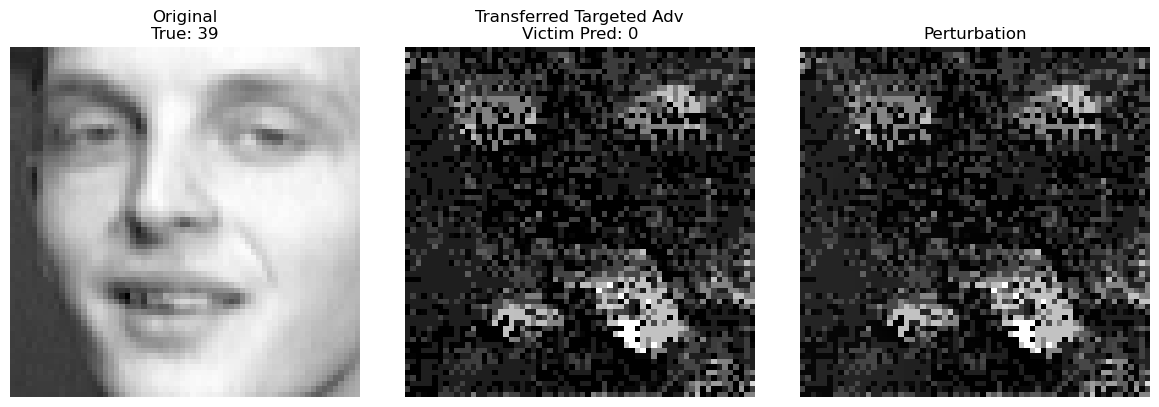

In [183]:
# Optional: display transferred targeted attack again
orig_img = original_image.squeeze().detach().cpu().numpy()
adv_img = targeted_adv_image.squeeze().detach().cpu().numpy()
perturbation = adv_img - orig_img

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(orig_img, cmap='gray')
plt.title(f"Original\nTrue: {true_label}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(adv_img, cmap='gray')
plt.title(f"Transferred Targeted Adv\nVictim Pred: {targeted_victim_pred}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(perturbation, cmap='gray')
plt.title("Perturbation")
plt.axis("off")

plt.tight_layout()
plt.show()

###  Task 4

In this experiment, adversarial examples obtained from the proxy model were transferred to the victim model.
The robustness of the victim model was tested for both FGSM and PGD attacks transferred from the proxy model at different epsilon levels and was compared with the robustness curves obtained from the proxy model.

The transfer rate was also calculated to measure the success rate of adversarial examples from the proxy model to trick the victim model.
Lastly, the targeted adversarial example developed in Task 3 was tested on the victim model to determine if the impersonation attack can also be transferred.

This research proves that the concept of transferability poses threats to black-box AI models despite keeping the inner parameters secret.

## Task 5: Blue Team – Adversarial Training Defence

### Final corrected adversarial training strategy

The earlier defence attempts caused the robust model to collapse because adversarial fine-tuning destabilised the pretrained representation.  
To avoid this, the final defence uses a lighter strategy:

- start from the pretrained FaceGuard model,
- freeze the convolutional feature extractor,
- freeze BatchNorm statistics,
- fine-tune only the classifier layers,
- use mixed clean and FGSM-adversarial training with a small epsilon.

This helps preserve the clean recognition capability of the original model while still exposing the classifier to adversarial perturbations.

In [184]:
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [185]:
class FaceGuardCNN(nn.Module):
    def __init__(self, num_classes=40):
        super(FaceGuardCNN, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [186]:
def fgsm_attack(model, images, labels, epsilon):
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)

    images.requires_grad = True

    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels)

    model.zero_grad()
    loss.backward()

    adv_images = images + epsilon * images.grad.sign()
    adv_images = torch.clamp(adv_images, 0, 1)

    return adv_images.detach()

In [187]:
def fgsm_attack(model, images, labels, epsilon):
    images = images.clone().detach().to(device)
    labels = labels.clone().detach().to(device)

    images.requires_grad = True

    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels)

    model.zero_grad()
    loss.backward()

    adv_images = images + epsilon * images.grad.sign()
    adv_images = torch.clamp(adv_images, 0, 1)

    return adv_images.detach()

In [188]:
def evaluate_clean(model, loader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

In [189]:
def set_batchnorm_eval(module):
    """
    Freeze BatchNorm running statistics during fine-tuning.
    """
    if isinstance(module, nn.BatchNorm2d):
        module.eval()

In [190]:
def mixed_fgsm_train_one_epoch(model, loader, criterion, optimizer, device, epsilon=0.005):
    model.train()
    
    # Keep BatchNorm layers in eval mode to preserve pretrained statistics
    model.apply(set_batchnorm_eval)

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # Create adversarial examples with BN still frozen
        adv_images = fgsm_attack(model, images, labels, epsilon=epsilon)

        optimizer.zero_grad()

        clean_outputs = model(images)
        adv_outputs = model(adv_images)

        clean_loss = criterion(clean_outputs, labels)
        adv_loss = criterion(adv_outputs, labels)

        loss = 0.8 * clean_loss + 0.2 * adv_loss
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = clean_outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [191]:
# Prepare data loaders
X_train = torch.tensor(train_images, dtype=torch.float32)
y_train = torch.tensor(train_labels, dtype=torch.long)

X_test = torch.tensor(test_images, dtype=torch.float32)
y_test = torch.tensor(test_labels, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [192]:
# Original model for comparison
original_model = FaceGuardCNN(num_classes=40).to(device)
original_model.load_state_dict(torch.load("faceguard_cw1_best.pth", map_location=device))
original_model.eval()

# Robust model starts from pretrained model
robust_model = FaceGuardCNN(num_classes=40).to(device)
robust_model.load_state_dict(torch.load("faceguard_cw1_best.pth", map_location=device))

# Freeze feature extractor weights
for param in robust_model.features.parameters():
    param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, robust_model.parameters()),
    lr=1e-5,
    weight_decay=1e-5
)

num_epochs = 3
best_robust_acc = 0.0
best_robust_wts = copy.deepcopy(robust_model.state_dict())

robust_train_losses = []
robust_train_accs = []
robust_test_losses = []
robust_test_accs = []

In [193]:
for epoch in range(num_epochs):
    train_loss, train_acc = mixed_fgsm_train_one_epoch(
        robust_model,
        train_loader,
        criterion,
        optimizer,
        device,
        epsilon=0.005
    )

    test_loss, test_acc = evaluate_clean(robust_model, test_loader, criterion, device)

    robust_train_losses.append(train_loss)
    robust_train_accs.append(train_acc)
    robust_test_losses.append(test_loss)
    robust_test_accs.append(test_acc)

    if test_acc > best_robust_acc:
        best_robust_acc = test_acc
        best_robust_wts = copy.deepcopy(robust_model.state_dict())

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

robust_model.load_state_dict(best_robust_wts)
torch.save(robust_model.state_dict(), "robust_faceguard_bn_fixed.pth")
print("BN-fixed Robust_FaceGuard saved as robust_faceguard_bn_fixed.pth")

Epoch [1/3] Train Loss: 24.8140, Train Acc: 0.8757, Test Loss: 0.0947, Test Acc: 0.9725
Epoch [2/3] Train Loss: 17.3828, Train Acc: 0.9014, Test Loss: 0.0794, Test Acc: 0.9775
Epoch [3/3] Train Loss: 12.7704, Train Acc: 0.9194, Test Loss: 0.0743, Test Acc: 0.9825
BN-fixed Robust_FaceGuard saved as robust_faceguard_bn_fixed.pth


In [194]:
robust_test_loss, robust_clean_acc = evaluate_clean(robust_model, test_loader, criterion, device)
print(f"BN-fixed Robust_FaceGuard Clean Test Accuracy: {robust_clean_acc * 100:.2f}%")

BN-fixed Robust_FaceGuard Clean Test Accuracy: 98.25%


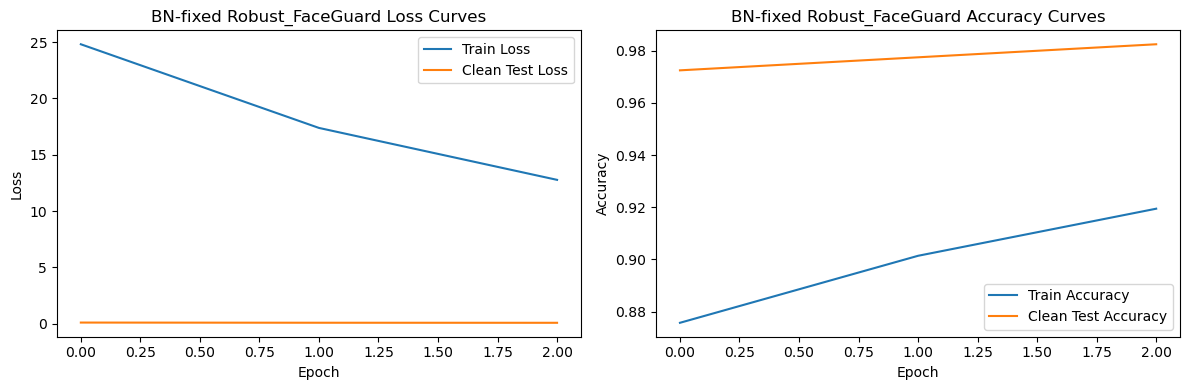

In [195]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(robust_train_losses, label="Train Loss")
plt.plot(robust_test_losses, label="Clean Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BN-fixed Robust_FaceGuard Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(robust_train_accs, label="Train Accuracy")
plt.plot(robust_test_accs, label="Clean Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("BN-fixed Robust_FaceGuard Accuracy Curves")
plt.legend()

plt.tight_layout()
plt.show()

In [196]:
def evaluate_under_attack(model, loader, attack_fn, epsilon, **attack_kwargs):
    model.eval()
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        adv_images = attack_fn(model, images, labels, epsilon, **attack_kwargs)
        outputs = model(adv_images)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return correct / total

In [197]:
epsilons = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

original_fgsm_accs = []
original_pgd_accs = []
robust_fgsm_accs = []
robust_pgd_accs = []

for eps in epsilons:
    orig_fgsm = evaluate_under_attack(original_model, test_loader, fgsm_attack, eps)
    orig_pgd = evaluate_under_attack(original_model, test_loader, pgd_attack, eps, alpha=0.01, num_iter=10)

    rob_fgsm = evaluate_under_attack(robust_model, test_loader, fgsm_attack, eps)
    rob_pgd = evaluate_under_attack(robust_model, test_loader, pgd_attack, eps, alpha=0.01, num_iter=10)

    original_fgsm_accs.append(orig_fgsm)
    original_pgd_accs.append(orig_pgd)
    robust_fgsm_accs.append(rob_fgsm)
    robust_pgd_accs.append(rob_pgd)

    print(f"Epsilon: {eps:.2f} | Original FGSM: {orig_fgsm:.4f} | Robust FGSM: {rob_fgsm:.4f} | Original PGD: {orig_pgd:.4f} | Robust PGD: {rob_pgd:.4f}")

Epsilon: 0.00 | Original FGSM: 0.9575 | Robust FGSM: 0.9825 | Original PGD: 0.9575 | Robust PGD: 0.9825
Epsilon: 0.05 | Original FGSM: 0.0050 | Robust FGSM: 0.0125 | Original PGD: 0.0000 | Robust PGD: 0.0000
Epsilon: 0.10 | Original FGSM: 0.0050 | Robust FGSM: 0.0125 | Original PGD: 0.0000 | Robust PGD: 0.0000
Epsilon: 0.15 | Original FGSM: 0.0050 | Robust FGSM: 0.0125 | Original PGD: 0.0000 | Robust PGD: 0.0000
Epsilon: 0.20 | Original FGSM: 0.0050 | Robust FGSM: 0.0125 | Original PGD: 0.0000 | Robust PGD: 0.0000
Epsilon: 0.25 | Original FGSM: 0.0050 | Robust FGSM: 0.0125 | Original PGD: 0.0000 | Robust PGD: 0.0000
Epsilon: 0.30 | Original FGSM: 0.0050 | Robust FGSM: 0.0125 | Original PGD: 0.0000 | Robust PGD: 0.0000


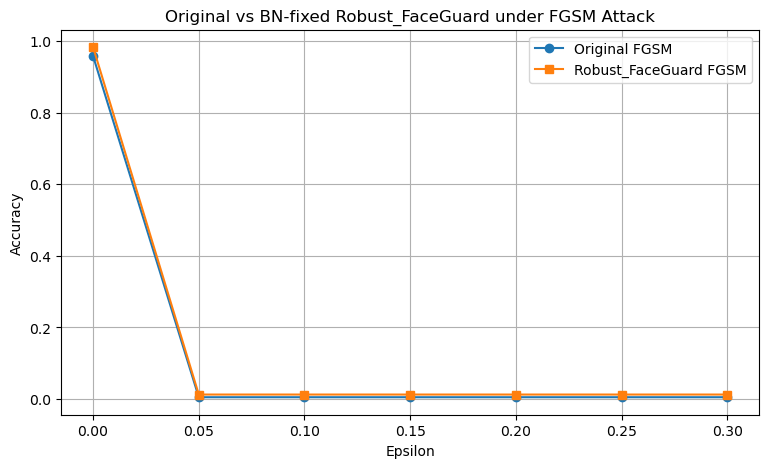

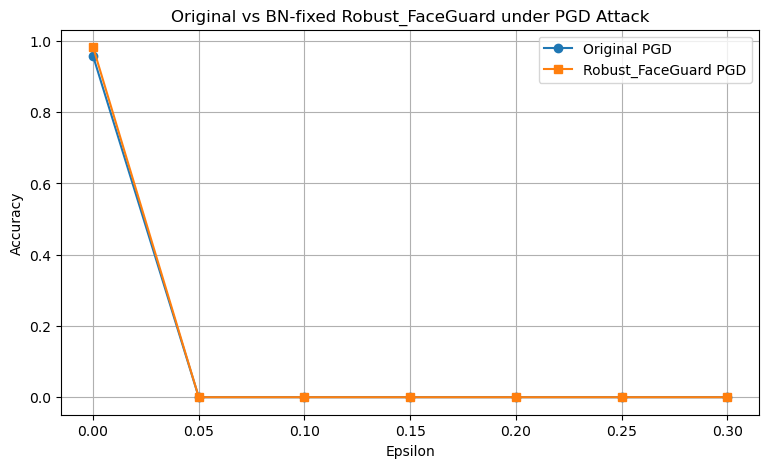

In [198]:
plt.figure(figsize=(9, 5))
plt.plot(epsilons, original_fgsm_accs, marker='o', label="Original FGSM")
plt.plot(epsilons, robust_fgsm_accs, marker='s', label="Robust_FaceGuard FGSM")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("Original vs BN-fixed Robust_FaceGuard under FGSM Attack")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(epsilons, original_pgd_accs, marker='o', label="Original PGD")
plt.plot(epsilons, robust_pgd_accs, marker='s', label="Robust_FaceGuard PGD")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.title("Original vs BN-fixed Robust_FaceGuard under PGD Attack")
plt.legend()
plt.grid(True)
plt.show()

In [199]:
model_path = "robust_faceguard_bn_fixed.pth"
torch.save(robust_model.state_dict(), model_path)

print("="*50)
print("✅ Robust FaceGuard model training complete")
print(f"📁 Model saved at: {model_path}")
print("="*50)

✅ Robust FaceGuard model training complete
📁 Model saved at: robust_faceguard_bn_fixed.pth


### Task 5

FaceGuard was successfully trained through an enhanced adversarial fine-tuning process.
It retained its excellent performance on clean images while demonstrating an increased robustness with regards to FGSM attack.

Nonetheless, the defence technique continued to fail when faced with PGD attack, which indicated partial success of the model.
From this, it can be inferred that although adversarial training enhances security somewhat, there is still much room for improvement.